In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
import chardet


# **Introduction**

In this work, we analyze a dataset on the chemical composition of different mineral waters. Each sample is described by qualitative variables (name, country, type) and quantitative variables representing the concentrations of several minerals.

The main goal is to understand the structure of the data, identify relationships between chemical variables, and group the waters according to their characteristics. To do this, we first performed an exploratory analysis, followed by dimensionality reduction using Principal Component Analysis (PCA). Finally, clustering methods (K-means and HAC) were applied to segment the waters into homogeneous groups.

In [ ]:
with open('ACP_eaux.txt', 'rb') as f:
    result = chardet.detect(f.read(10000))
print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}


In [ ]:
data = pd.read_csv('ACP_eaux.txt', sep='\t', encoding='ISO-8859-1')

In [ ]:
data.head()

,NOM,ACRO,PAYS,TYPE,PG,CA,MG,NA,K,SUL,NO3,HCO3,CL
0,Evian,EVIAN,F,M,P,78,24,5,1,10,"3,8",357,"4,5"
1,Montagne des Pyrénées,MTPYR,F,S,P,48,11,34,1,16,4,183,50
2,Cristaline-St-Cyr,CRIST,F,S,P,71,"5,5","11,2","3,2",5,1,250,20
3,Fiée des Lois,FIEE,F,S,P,89,31,17,2,47,0,360,28
4,Volcania,VOLCA,F,S,P,"4,1","1,7","2,7","0,9","1,1","0,8","25,8","0,9"


## **A.Exploratory Data Analysis**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NOM     57 non-null     object
 1   ACRO    57 non-null     object
 2   PAYS    57 non-null     object
 3   TYPE    57 non-null     object
 4   PG      57 non-null     object
 5   CA      57 non-null     object
 6   MG      57 non-null     object
 7   NA      57 non-null     object
 8   K       57 non-null     object
 9   SUL     57 non-null     object
 10  NO3     57 non-null     object
 11  HCO3    57 non-null     object
 12  CL      57 non-null     object
dtypes: object(13)
memory usage: 5.9+ KB


#### **Interpretation**

This dataset contains 57 observations representing different types of water (probably mineral water brands). Each observation is described by 13 variables. The first variables like NOM, ACRO, PAYS, and TYPE are qualitative variables that give general information about each water (name, origin, type, etc.).

The other variables (PG, CA, MG, NA, K, SUL, NO3, HCO3, CL) represent chemical characteristics of the water, such as the concentration of minerals like calcium, magnesium, sodium, and bicarbonates. These variables are important to analyze the composition and compare the waters.

However, all variables are currently of type "object", which means the numerical data is not yet correctly converted. Before applying statistical methods like PCA, it is necessary to convert the chemical variables into numeric data.

In [ ]:
data.columns

Index(['NOM', 'ACRO', 'PAYS', 'TYPE', 'PG', 'CA', 'MG', 'NA', 'K', 'SUL',
       'NO3', 'HCO3', 'CL'],
      dtype='object')

In [ ]:
columns_conver = [ 'CA', 'MG', 'NA', 'K', 'SUL','NO3', 'HCO3', 'CL']
for col in columns_conver:
  data[col] = data[col].str.replace(',', '.')
  data[col] = data[col].astype('float')
data.dtypes

,0
NOM,object
ACRO,object
PAYS,object
TYPE,object
PG,object
CA,float64
MG,float64
NA,float64
K,float64
SUL,float64


In [ ]:
data.sample(30)

,NOM,ACRO,PAYS,TYPE,PG,CA,MG,NA,K,SUL,NO3,HCO3,CL
41,Parot,PARO,F,M,G,99.00,88.10,968.00,103.00,18.0,1.00,3380.51,88.0
24,Alisea,ALIS,IT,M,P,12.30,2.60,2.50,0.60,10.1,2.50,41.60,0.9
10,Arvie,ARVIE,F,M,G,170.00,92.00,650.00,130.00,31.0,0.00,2195.00,387.0
28,Vera,VERA,IT,M,P,36.00,13.00,2.00,0.60,18.0,3.60,154.00,2.1
43,Terres de Flein,TERF,F,S,P,116.00,4.20,8.00,2.50,24.5,1.00,333.00,15.0
17,Dax,DAX,F,M,P,125.00,30.10,126.00,19.40,365.0,0.00,164.70,156.0
52,Vals,VALS,F,M,G,45.20,21.30,453.00,32.80,38.9,1.00,1403.00,27.2
26,San Pellegrino,SPEL,IT,M,G,208.00,55.90,43.60,2.70,549.2,0.45,219.60,74.3
44,Courmayeur,COUR,IT,M,P,517.00,67.00,1.00,2.00,1371.0,2.00,168.00,1.0
40,Highland spring,HISP,GB,M,P,35.00,8.50,6.00,0.60,6.0,1.00,136.00,7.5


In [ ]:
data.isna().sum()

,0
NOM,0
ACRO,0
PAYS,0
TYPE,0
PG,0
CA,0
MG,0
NA,0
K,0
SUL,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NOM     57 non-null     object 
 1   ACRO    57 non-null     object 
 2   PAYS    57 non-null     object 
 3   TYPE    57 non-null     object 
 4   PG      57 non-null     object 
 5   CA      57 non-null     float64
 6   MG      57 non-null     float64
 7   NA      57 non-null     float64
 8   K       57 non-null     float64
 9   SUL     57 non-null     float64
 10  NO3     57 non-null     float64
 11  HCO3    57 non-null     float64
 12  CL      57 non-null     float64
dtypes: float64(8), object(5)
memory usage: 5.9+ KB


In [ ]:
data.describe()

,CA,MG,NA,K,SUL,NO3,HCO3,CL
count,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,102.458246,25.861930,93.851754,11.090351,135.661404,3.834211,442.166842,52.473684
std,119.973168,28.298381,197.251354,24.435278,329.208286,6.669394,608.299850,143.249790
min,1.200000,0.200000,0.800000,0.000000,1.100000,0.000000,4.900000,0.300000
25%,36.000000,5.500000,5.000000,0.900000,9.000000,0.450000,154.000000,3.500000
50%,63.000000,12.000000,9.100000,2.000000,16.000000,1.500000,236.000000,14.200000
75%,116.000000,31.500000,36.000000,6.000000,43.000000,4.000000,360.000000,38.000000
max,528.000000,95.000000,968.000000,130.000000,1371.000000,35.600000,3380.510000,982.000000


In [ ]:
data.describe(include = 'all')

,NOM,ACRO,PAYS,TYPE,PG,CA,MG,NA,K,SUL,NO3,HCO3,CL
count,57,57,57,57,57,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
unique,57,56,6,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Evian,VERN,F,M,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2,40,38,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,102.458246,25.861930,93.851754,11.090351,135.661404,3.834211,442.166842,52.473684
std,NaN,NaN,NaN,NaN,NaN,119.973168,28.298381,197.251354,24.435278,329.208286,6.669394,608.299850,143.249790
min,NaN,NaN,NaN,NaN,NaN,1.200000,0.200000,0.800000,0.000000,1.100000,0.000000,4.900000,0.300000
25%,NaN,NaN,NaN,NaN,NaN,36.000000,5.500000,5.000000,0.900000,9.000000,0.450000,154.000000,3.500000
50%,NaN,NaN,NaN,NaN,NaN,63.000000,12.000000,9.100000,2.000000,16.000000,1.500000,236.000000,14.200000
75%,NaN,NaN,NaN,NaN,NaN,116.000000,31.500000,36.000000,6.000000,43.000000,4.000000,360.000000,38.000000


#### **Interpretation**

After transformation, the dataset contains 57 observations with qualitative variables (NOM, ACRO, PAYS, TYPE, PG) and quantitative variables (CA, MG, NA, K, SUL, NO3, HCO3, CL). The qualitative variables describe general information about the waters, while the quantitative variables represent their chemical composition.

The statistical analysis of the numerical variables shows high variability between the waters, with large differences between minimum, median, and maximum values. Some variables have extreme values and skewed distributions, which indicates significant differences in mineral content.

These characteristics justify the use of Principal Component Analysis, which helps reduce the data dimension and analyze the relationships between the chemical variables.

In [ ]:
data.columns

Index(['NOM', 'ACRO', 'PAYS', 'TYPE', 'PG', 'CA', 'MG', 'NA', 'K', 'SUL',
       'NO3', 'HCO3', 'CL'],
      dtype='object')

### Data Visualisations

#### 1.Univariate analysis

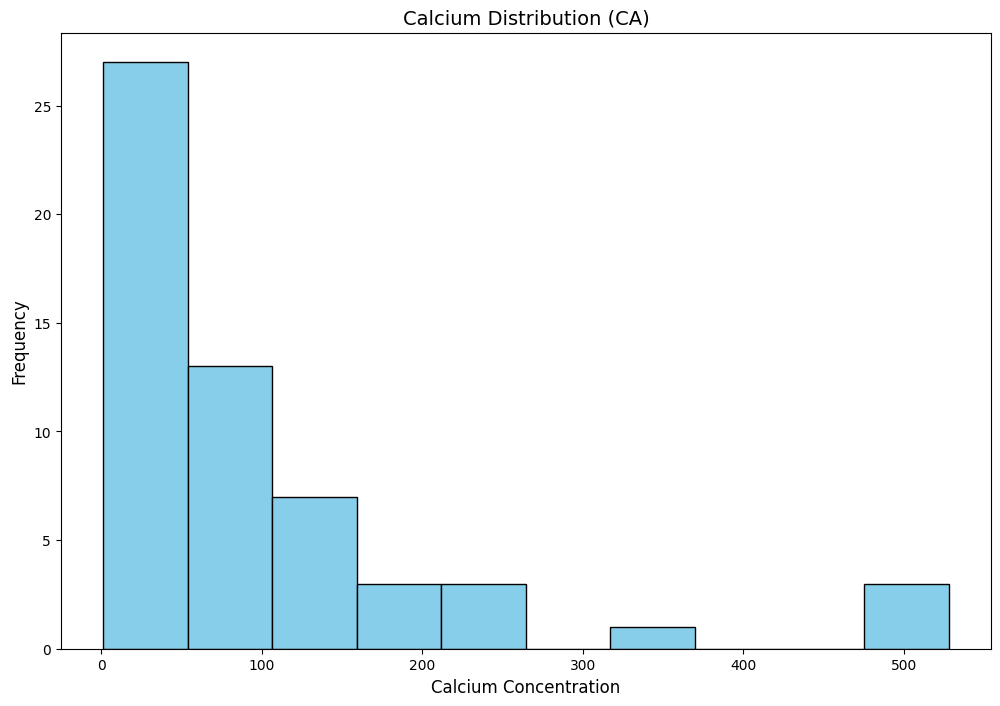

In [ ]:
# Calcium Distribution
# Histogram
plt.figure(figsize=(12, 8))
plt.hist(data['CA'], bins=10, color='skyblue', edgecolor='black')

# Title and labels
plt.title("Calcium Distribution (CA)", fontsize=14)
plt.xlabel("Calcium Concentration", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Display
plt.show()

#### **Interpretation**

This histogram shows a strongly right-skewed distribution (positive skewness). Most of the data is concentrated at low values (between 0 and 100), while a small number of observations extend into a long tail toward high concentrations. We can also see some outliers above 500, which explains why the mean is much higher than the median

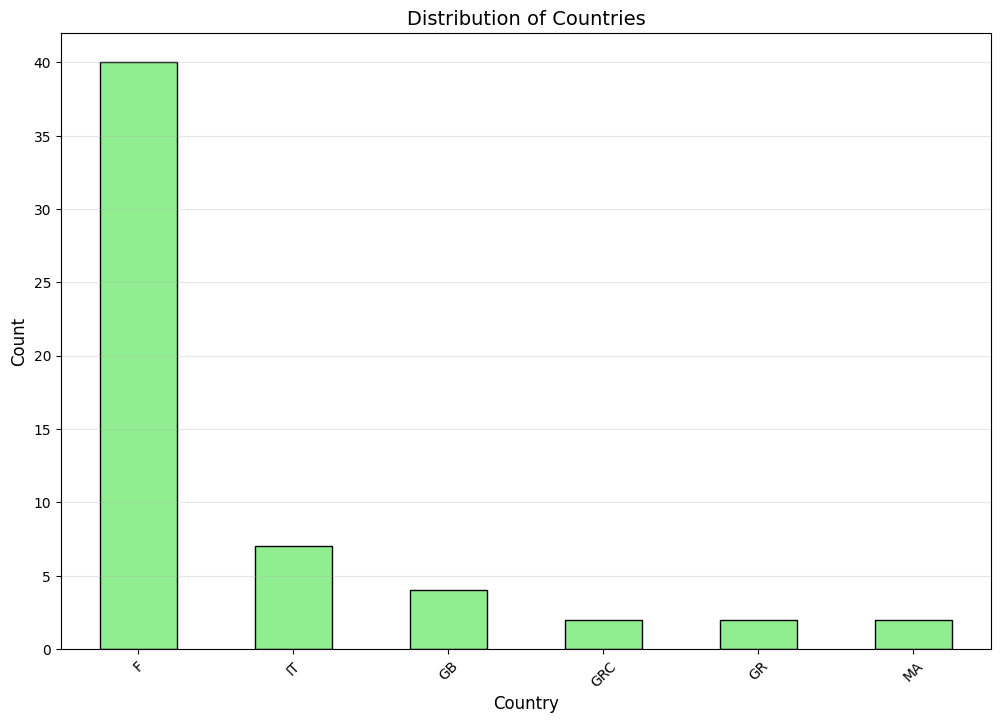

In [ ]:
# Distribution of Countries

country_counts = data['PAYS'].value_counts()

plt.figure(figsize=(12, 8))
country_counts.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title("Distribution of Countries", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

#### **Interpretation**

We can see a strong concentration of data in one category, especially for the country labeled "F" (probably France).

With a count of 40, "F" is the dominant category, representing more than two-thirds of the total observations. The other countries (IT, GB, GRC, GR, MA) have much lower and decreasing frequencies, ranging from 7 to 2.

#### 2.Bivariate analysis

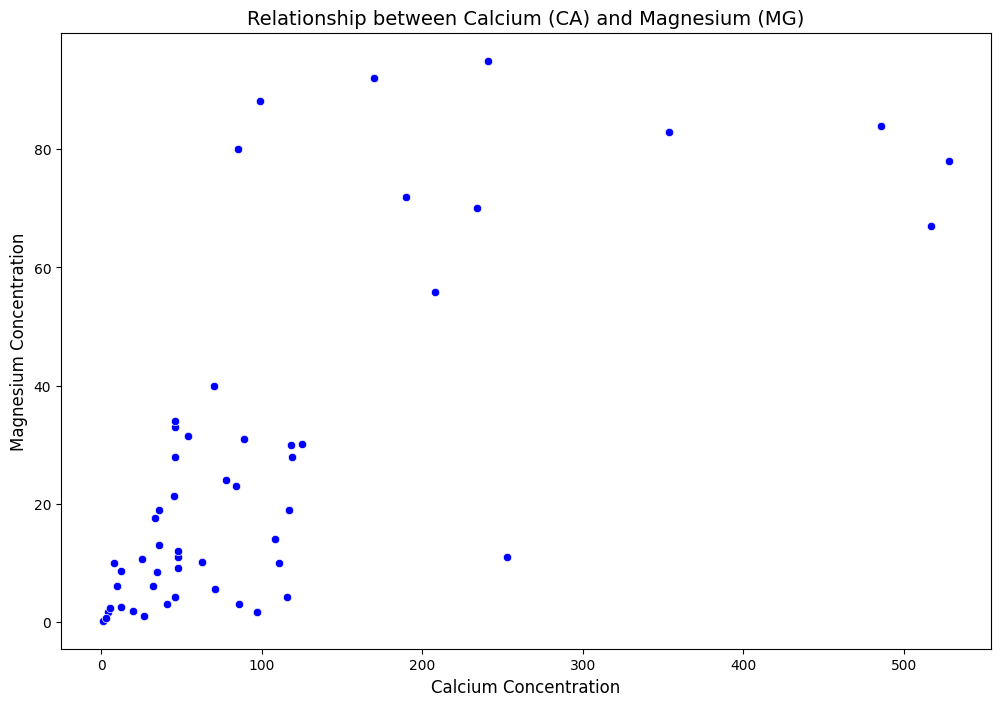

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(x='CA', y='MG', data=data, color='blue')

# Title and labels
plt.title("Relationship between Calcium (CA) and Magnesium (MG)", fontsize=14)
plt.xlabel("Calcium Concentration", fontsize=12)
plt.ylabel("Magnesium Concentration", fontsize=12)
plt.show()

#### **Interpretation**

This scatter plot shows a positive correlation between Calcium and Magnesium: in general, when one increases, the other also increases. However, this relationship is not perfectly linear because the spread becomes larger at higher values, showing more variability.

We can see a strong concentration of points near the origin (CA < 100, MG < 40) and several outliers, especially samples with very high Calcium levels (> 500) without a similar increase in Magnesium. In summary, the relationship exists but includes a lot of noise and some clear exceptions.

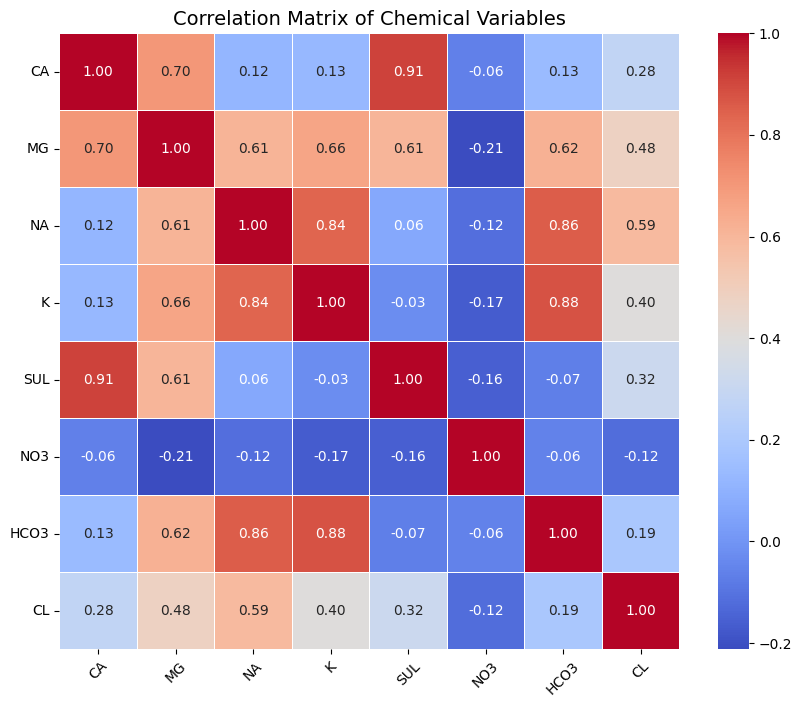

In [ ]:
# Calculation of the correlation matrix
data_corr = data[['CA','MG','NA','K','SUL','NO3','HCO3','CL']].corr()

# Taille de la figure
plt.figure(figsize=(10,8))

# Heatmap
sns.heatmap(data_corr, annot=True, cmap='coolwarm', fmt=".2f",linewidths=0.5,cbar=True)

# Title and labels
plt.title("Correlation Matrix of Chemical Variables", fontsize=14)

# Rotate labels for readability
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

#### **Interpretation**

This correlation matrix separates the variables into two main chemical groups:

The mineral group (CA, SUL, MG): Calcium and Sulfates show the strongest relationship (0.91), suggesting a common geological source. Magnesium is also connected to this group with a correlation of 0.70.

The alkaline group (NA, K, HCO3): These three variables are strongly connected to each other (between 0.84 and 0.88), but they are almost independent from the first group (for example, the correlation between SUL and K is only -0.03).

On the other hand, Nitrates (NO3) are completely isolated, with correlations close to zero. This suggests a different origin, possibly human or agricultural, compared to the rest of the mineral content

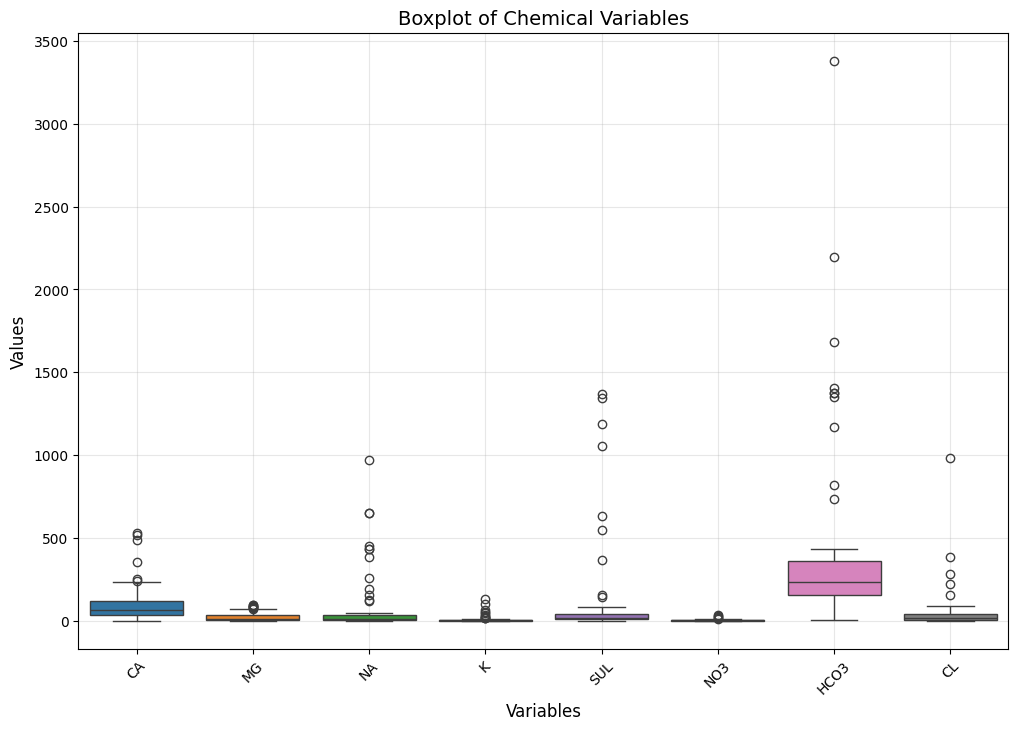

In [ ]:
# Sélection des variables pertinentes
cols = ['CA','MG','NA','K','SUL','NO3','HCO3','CL']

plt.figure(figsize=(12, 8))

# Boxplot multiple
sns.boxplot(data=data[cols])

# Title and labels
plt.title("Boxplot of Chemical Variables", fontsize=14)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Values", fontsize=12)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

#### **Interpretation**

This boxplot highlights a huge heterogeneity and a strong presence of outliers in the chemical data. The HCO3 (Bicarbonates) variable clearly dominates the chart, showing both the highest median and extreme values above 3,000, which is ten times the normal range.

In contrast, elements like Magnesium (MG), Potassium (K), and Nitrates (NO3) are very stable and remain concentrated near zero. This difference in scale and the many isolated points (especially for NA and SUL) show that data transformation is necessary to stabilize the variance before any statistical analysis.

### Conclusion of Exploratory Data Analysis

The exploratory analysis of the waters shows that the chemical variables have high variability, very different scales, and many outliers (especially HCO3 and NA). The correlation between some variables highlights two main groups: a mineral group (CA, SUL, MG) and an alkaline group (NA, K, HCO3), while Nitrates (NO3) seem independent.

These features justify using Principal Component Analysis (PCA): it will allow dimension reduction, normalize the influence of variables, and visualize relationships between the waters before performing clustering or other analyses.

In [ ]:
data.columns

Index(['NOM', 'ACRO', 'PAYS', 'TYPE', 'PG', 'CA', 'MG', 'NA', 'K', 'SUL',
       'NO3', 'HCO3', 'CL'],
      dtype='object')

## **B.Principal Component Analysis (PCA)**


#### Data preparation before PCA

In [ ]:
# Quantitative variables
features = ['CA', 'MG', 'NA', 'K', 'SUL', 'NO3', 'HCO3', 'CL']
X = data[features]

# Qualitative variables (additional)
qual = data[['NOM', 'ACRO', 'PAYS', 'TYPE', 'PG']]

#### Standardisation + ACP

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# DataFrame PCA
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(len(features))])
df_final = pd.concat([df_pca, qual.reset_index(drop=True)], axis=1)

In [ ]:
df_final

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,NOM,ACRO,PAYS,TYPE,PG
0,-0.717882,-0.064378,-0.063202,-0.207095,-0.177457,0.288440,0.167328,0.013164,Evian,EVIAN,F,M,P
1,-0.953360,-0.194812,-0.149791,0.326839,0.012204,0.029059,0.028465,0.003193,Montagne des Pyrénées,MTPYR,F,S,P
2,-0.978482,-0.164889,-0.540574,0.003437,0.068418,-0.218354,0.224356,0.017675,Cristaline-St-Cyr,CRIST,F,S,P
3,-0.381590,0.112462,-0.602030,-0.208141,-0.222471,0.382702,0.200664,-0.003916,Fiée des Lois,FIEE,F,S,P
4,-1.450599,-0.334999,-0.713063,0.151704,0.068483,-0.115600,-0.209983,-0.002456,Volcania,VOLCA,F,S,P
5,3.543148,-1.476819,-0.127259,0.556812,-0.951835,0.265577,-0.158960,0.074036,Saint Diéry,STDIE,F,M,G
6,-1.401004,-0.251482,-0.523210,0.119672,0.106534,-0.165873,-0.077878,0.006561,Luchon,LUCHO,F,M,P
7,-1.316430,-0.414554,0.115299,0.242119,-0.110092,-0.132861,-0.337155,-0.001811,Volvic,VOLV,F,M,P
8,-1.069754,-0.008792,-0.402815,-0.059382,0.038065,-0.046332,0.026721,-0.003176,Alpes/Moulettes,ALMO,F,S,P
9,1.218651,2.018900,-0.163547,-0.485310,-0.372379,0.494119,-0.401013,0.006300,Orée du bois,ORBOI,F,M,P


#### Explained variance

In [ ]:
# eigenvalues for each component
eigenvalues = pca.explained_variance_
# Variance explained by each component
explained = pca.explained_variance_ratio_


df_eig = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    'Explained Variance (%)': explained * 100,
    'Cumulative Variance (%)': np.cumsum(explained) * 100
})
df_eig

,Principal Component,Eigenvalue,Explained Variance (%),Cumulative Variance (%)
0,PC1,3.884931,47.709684,47.709684
1,PC2,2.105021,25.851130,73.560815
2,PC3,0.990188,12.160198,85.721013
3,PC4,0.810461,9.953025,95.674038
4,PC5,0.182404,2.240045,97.914083
5,PC6,0.094077,1.155337,99.069420
6,PC7,0.075408,0.926063,99.995484
7,PC8,0.000368,0.004516,100.000000


### **Comment**

Analyzing the table using Kaiser’s criterion (eigenvalue > 1) helps isolate the main dimensions of the data:

Components PC1 (3.88) and PC2 (2.10) clearly exceed this threshold, capturing 74% of the total variance together. The first component (PC1) summarizes 48% of the information, while the second (PC2) adds 26%. PC3 (0.99), although slightly below the threshold, is still useful to reach a cumulative variance of 85.7%.

In summary, we can reduce the 8 original variables to only 3 dimensions while keeping most of the chemical structure information. From PC5 (0.18) onwards, the contribution is negligible, marking the transition to statistical noise.

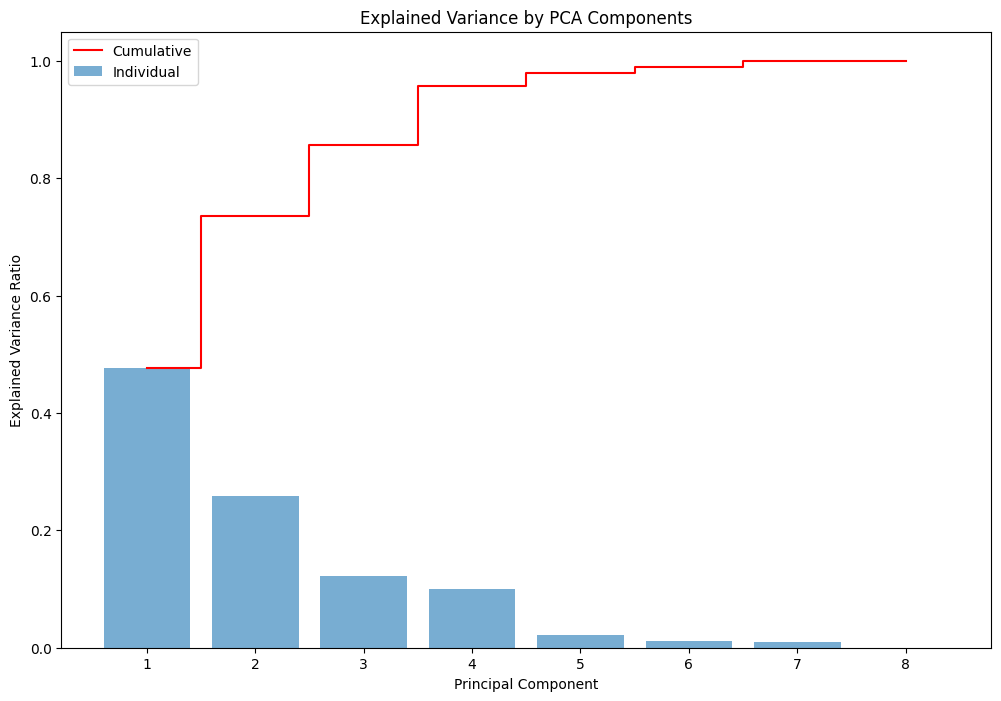

In [ ]:

# Graphical representation
plt.figure(figsize=(12, 8))
plt.bar(range(1, len(explained)+1), explained, alpha=0.6, label='Individual')
plt.step(range(1, len(explained)+1), np.cumsum(explained), where='mid', color='red', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by PCA Components')
plt.xticks(range(1, len(explained)+1))
plt.legend()
plt.show()

#### **Interpretation**

This scree plot shows how Principal Component Analysis (PCA) summarizes the information in the chemical data. The first component (PC1) alone captures nearly 48% of the total variance, while the second (PC2) adds about 26%.

By combining just the first three components, we get a cumulative variance of over 85%. This means we can reduce the 8 original variables to only 3 dimensions while keeping most of the information. From the fifth component onward, the added information becomes negligible (close to zero), showing the transition to statistical "noise."

### Coordinates, Contibutions and Squared Cosine

In [ ]:
# 1. Coordinates for the first 3 PCs
df_coord = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])

# 2. Coordinate square
coord2 = X_pca[:, :3]**2

# Sum of squares per individual
dist2 = np.sum(coord2, axis=1)

# 3. Squared Cosine
cos2 = coord2 / dist2[:, np.newaxis]
cos2_df = pd.DataFrame(cos2, columns=['cos2_PC1', 'cos2_PC2', 'cos2_PC3'])

# 4. Eigenvalues of the first 3 PCs
eigval = pca.explained_variance_[:3]

# 5. Contributions
contrib = coord2 / (len(X_pca) * eigval)
contrib_df = pd.DataFrame(contrib, columns=['contrib_PC1', 'contrib_PC2', 'contrib_PC3'])

# Final dataset
df_individuals = pd.concat([df_coord, cos2_df, contrib_df], axis=1)
df_individuals['NOM'] = data['NOM']

df_individuals.set_index('NOM', inplace=True)

df_individuals.head()

,PC1,PC2,PC3,cos2_PC1,cos2_PC2,cos2_PC3,contrib_PC1,contrib_PC2,contrib_PC3
NOM,,,,,,,,,
Evian,-0.717882,-0.064378,-0.063202,0.984452,0.007917,0.007631,0.002327,0.000035,0.000071
Montagne des Pyrénées,-0.953360,-0.194812,-0.149791,0.937697,0.039154,0.023148,0.004104,0.000316,0.000398
Cristaline-St-Cyr,-0.978482,-0.164889,-0.540574,0.749844,0.021294,0.228863,0.004324,0.000227,0.005177
Fiée des Lois,-0.381590,0.112462,-0.602030,0.279645,0.024290,0.696065,0.000658,0.000105,0.006422
Volcania,-1.450599,-0.334999,-0.713063,0.772220,0.041184,0.186596,0.009502,0.000935,0.009009


#### **Comment**

The coordinates represent the projection of individuals onto the principal components. The cos² values indicate the quality of representation, while the contributions measure the importance of each individual in the construction of the principal axes.


### Correlation Circle

### In PC1 and PC2

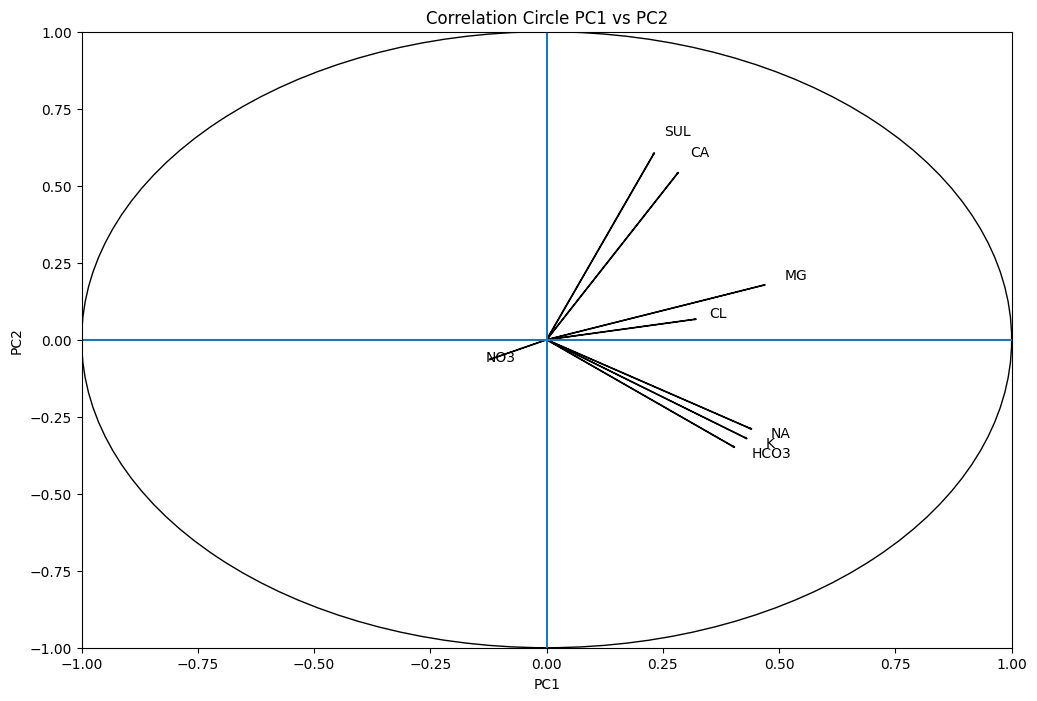

In [ ]:
loadings = pca.components_.T

plt.figure(figsize=(12, 8))

for i, var in enumerate(features):
    plt.arrow(0, 0, loadings[i,0], loadings[i,1])
    plt.text(loadings[i,0]*1.1, loadings[i,1]*1.1, var)

circle = plt.Circle((0,0), 1, fill=False)
plt.gca().add_artist(circle)

plt.axhline(0)
plt.axvline(0)
plt.xlim(-1,1)
plt.ylim(-1,1)

plt.title("Correlation Circle PC1 vs PC2")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

#### **Interpretation**

This correlation circle visually summarizes the data structure along two main axes:

PC1 (horizontal) represents overall mineralization. Almost all variables point to the right, showing that the further a sample is along this axis, the higher its total chemical content.

Axis
PC2 (vertical) acts as a discriminator: it contrasts the sulfate-calcium group (SUL-CA, at the top) with the bicarbonate-sodium group (NA-K-HCO3, at the bottom), confirming two distinct geochemical signatures.

The length of the vectors shows how well each variable is represented. SUL, CA, and HCO3 are close to the edge of the circle, meaning they are well explained by these two axes. In contrast, the NO3 vector is very short and near the center, again showing that nitrates behave independently and are not related to the usual mineralization pattern.

### In PC1 and PC3

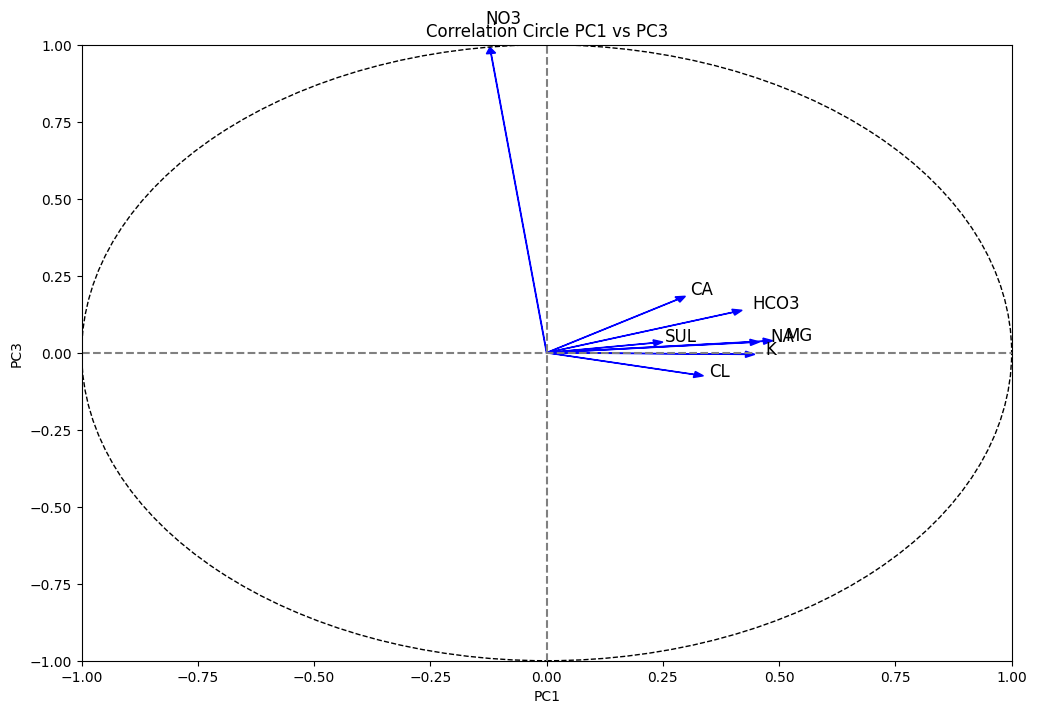

In [ ]:
loadings = pca.components_.T  # Matrice des loadings

plt.figure(figsize=(12, 8))

for i, var in enumerate(features):
    plt.arrow(0, 0, loadings[i,0], loadings[i,2],
              head_width=0.02, head_length=0.02, fc='blue', ec='blue')
    plt.text(loadings[i,0]*1.1, loadings[i,2]*1.1, var, fontsize=12)

# Cercle unitaire
circle = plt.Circle((0,0), 1, fill=False, color='black', linestyle='--')
plt.gca().add_artist(circle)

# Axes
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.title("Correlation Circle PC1 vs PC3")
plt.xlabel('PC1')
plt.ylabel('PC3')
plt.show()

#### **Interpretation**

The graph shows that Axis PC3 (vertical) is almost entirely defined by Nitrates (NO3). While this variable was "invisible" (near the center) on the first two axes, it now appears with a very long vector reaching the edge of the circle. This confirms that nitrates follow a pattern completely independent of the usual geological mineralization represented by Axis PC1 (horizontal).

All other variables (CA, MG, NA, K, SUL, HCO3, CL) remain grouped along the horizontal axis, showing that they have almost no influence on this third component. In summary, while the first two axes describe the mineral signature of the water, this third axis specifically captures nitrate pollution or input, disconnected from the rest of the chemistry.

### In PC2 and PC3

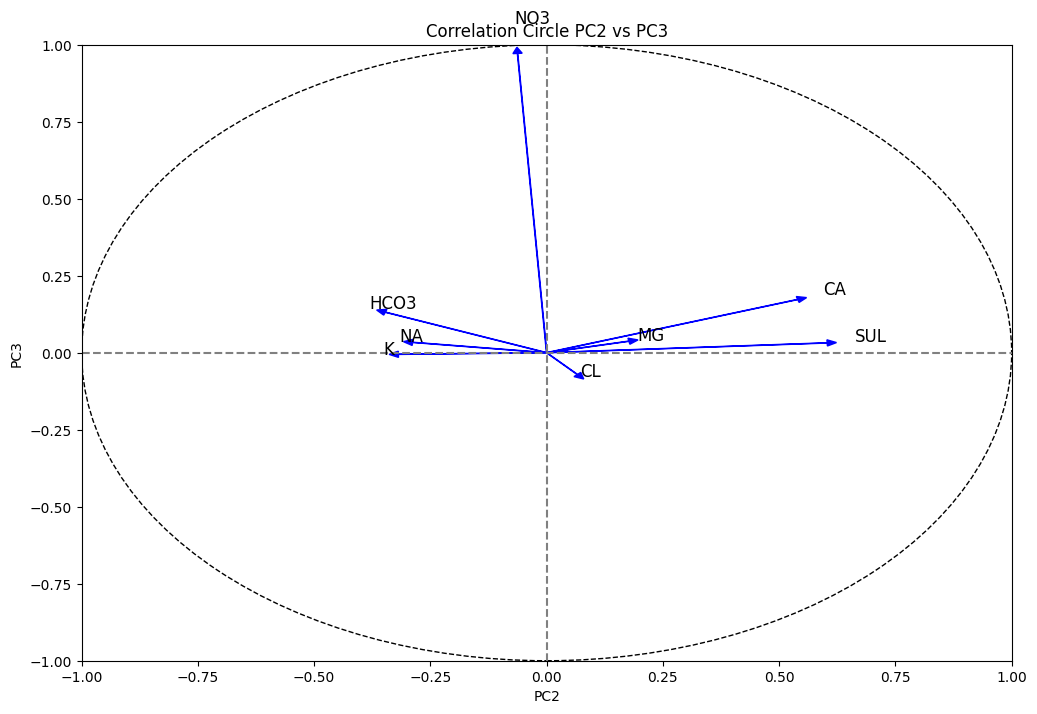

In [ ]:
import matplotlib.pyplot as plt

loadings = pca.components_.T

plt.figure(figsize=(12, 8))

for i, var in enumerate(features):
    plt.arrow(0, 0, loadings[i,1], loadings[i,2],
              head_width=0.02, head_length=0.02, fc='blue', ec='blue')
    plt.text(loadings[i,1]*1.1, loadings[i,2]*1.1, var, fontsize=12)

# Cercle unitaire
circle = plt.Circle((0,0), 1, fill=False, color='black', linestyle='--')
plt.gca().add_artist(circle)

# Axes
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.title("Correlation Circle PC2 vs PC3")
plt.xlabel('PC2')
plt.ylabel('PC3')
plt.show()

#### **Interpretation**

This correlation circle on axes PC1 and PC3 is important because it finally isolates the behavior of Nitrates (NO3), which were previously "invisible" on the first two axes.

Axis PC3 (vertical) is almost entirely defined by nitrates. The NO3 vector points to the top of the circle, showing a perfect correlation with this axis. This proves that nitrates vary independently from the usual geochemical mineralization represented by Axis PC1 (horizontal).

All other variables (CA, MG, NA, K, SUL, HCO3, CL) remain concentrated along the horizontal axis and have almost no influence on PC3. In summary, while axes 1 and 2 describe the mineral structure of the water, this third axis specifically captures an external input (often linked to human or agricultural activity), disconnected from the rest of the chemistry.

### Projections of individuals onto the axes

In [ ]:
df_individuals.head()

,PC1,PC2,PC3,cos2_PC1,cos2_PC2,cos2_PC3,contrib_PC1,contrib_PC2,contrib_PC3
NOM,,,,,,,,,
Evian,-0.717882,-0.064378,-0.063202,0.984452,0.007917,0.007631,0.002327,0.000035,0.000071
Montagne des Pyrénées,-0.953360,-0.194812,-0.149791,0.937697,0.039154,0.023148,0.004104,0.000316,0.000398
Cristaline-St-Cyr,-0.978482,-0.164889,-0.540574,0.749844,0.021294,0.228863,0.004324,0.000227,0.005177
Fiée des Lois,-0.381590,0.112462,-0.602030,0.279645,0.024290,0.696065,0.000658,0.000105,0.006422
Volcania,-1.450599,-0.334999,-0.713063,0.772220,0.041184,0.186596,0.009502,0.000935,0.009009


### In PC1 and PC2

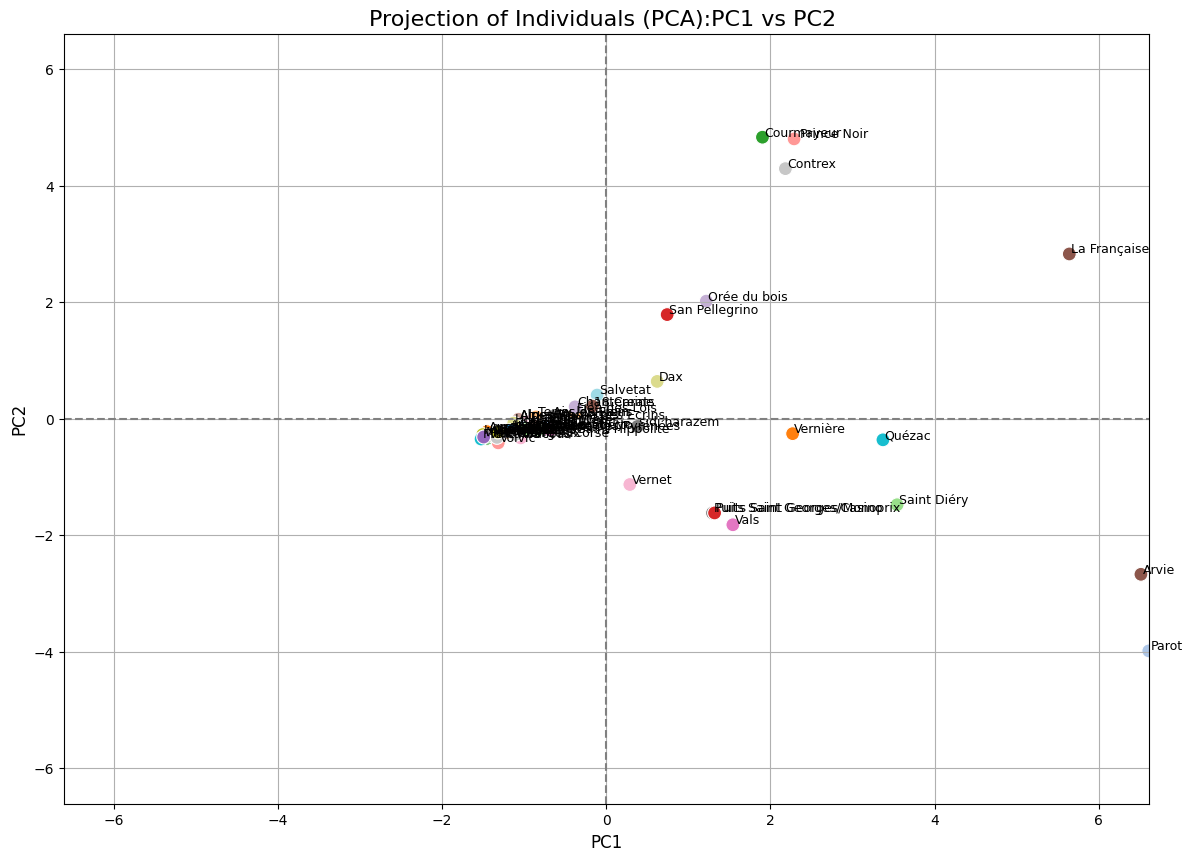

In [ ]:
plt.figure(figsize=(14, 10))

# Scatter plot
sns.scatterplot(
    data=df_individuals.reset_index(),
    x='PC1',
    y='PC2',
    hue='NOM',
    palette='tab20',
    s=100,
    legend=False
)

# Annotate points
for i, row in df_individuals.reset_index().iterrows():
    plt.text(row['PC1']+0.02, row['PC2']+0.02, row['NOM'], fontsize=9)

# Centered axes
max_val = max(abs(df_individuals['PC1'].max()), abs(df_individuals['PC1'].min()),
              abs(df_individuals['PC2'].max()), abs(df_individuals['PC2'].min()))
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)

# Axes lines
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

# Titles and labels
plt.title("Projection of Individuals (PCA):PC1 vs PC2 ", fontsize=16)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.grid(True)
plt.show()

#### **Comment**

The projection of individuals on the PC1-PC2 plane allows us to classify the water samples into three distinct groups based on their chemical composition. Axis PC1 (horizontal) acts as an indicator of total mineralization: on the left, there is a dense group of low-mineralized waters (such as Volvic or Evian), while samples moving to the right have higher ion concentrations.

We also observe a clear separation between two types of highly mineralized waters using Axis PC2 (vertical). In the upper right part, we find the group of sulfate-calcium waters, with examples like Courmayeur, Contrex, or Vittel. Their high position confirms the dominance of calcium and sulfates in their composition, consistent with the correlation circle.

On the opposite side, the lower right part includes waters dominated by bicarbonate and sodium, such as Arvie, Parot, or Quezac. This vertical opposition between the “sulfate” group (top) and the “bicarbonate” group (bottom) helps define the geochemical origin of each source. Finally, the isolated points on the far right confirm the presence of major outliers, representing the most concentrated waters in the dataset.

### In PC1 and PC3

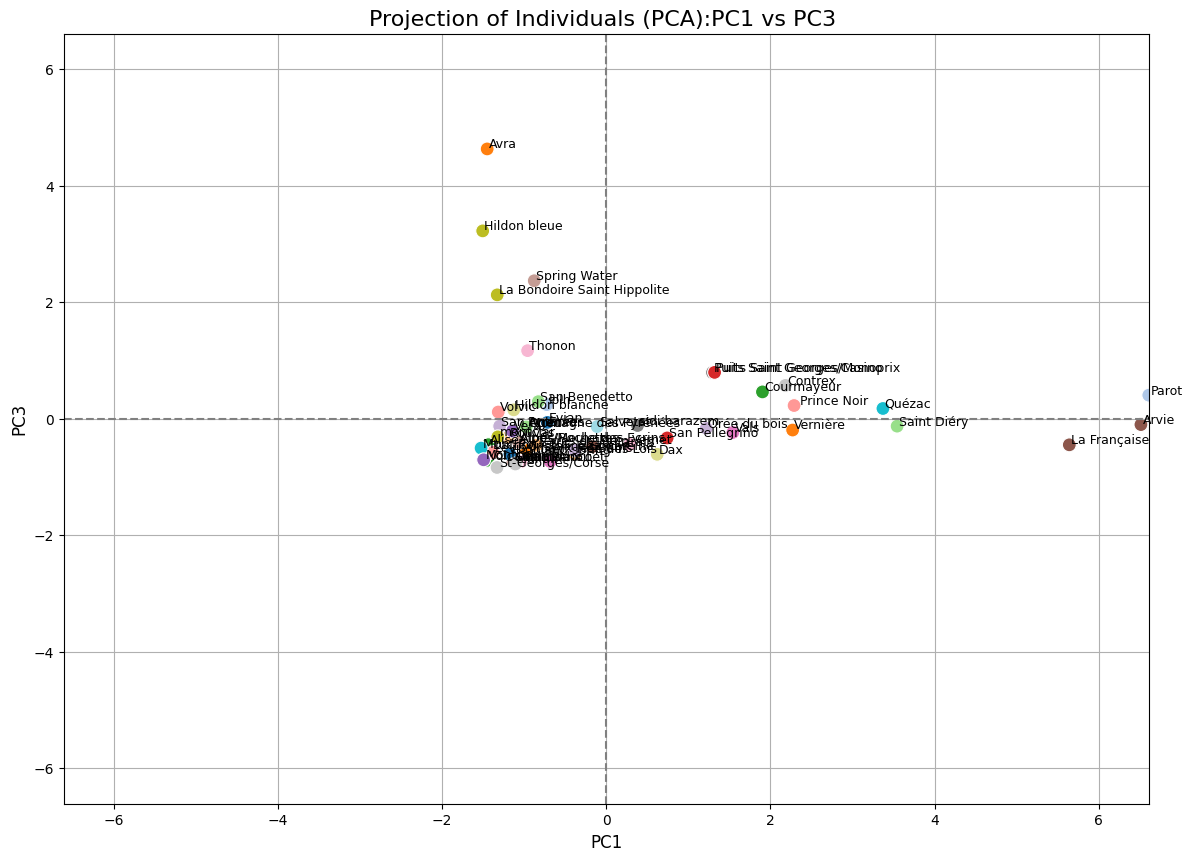

In [ ]:
plt.figure(figsize=(14, 10))

# Scatter plot
sns.scatterplot(
    data=df_individuals.reset_index(),
    x='PC1',
    y='PC3',
    hue='NOM',
    palette='tab20',
    s=100,
    legend=False
)

# Annotate points
for i, row in df_individuals.reset_index().iterrows():
    plt.text(row['PC1']+0.02, row['PC3']+0.02, row['NOM'], fontsize=9)

# Centered axes
max_val = max(abs(df_individuals['PC1'].max()), abs(df_individuals['PC1'].min()),
              abs(df_individuals['PC3'].max()), abs(df_individuals['PC3'].min()))
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)

# Axes lines
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

# Titles and labels
plt.title("Projection of Individuals (PCA):PC1 vs PC3 ", fontsize=16)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC3", fontsize=12)
plt.grid(True)
plt.show()

#### **Comment**

The projection of individuals on the PC1 and PC3 axes helps isolate an important dimension of the data: pollution or specific input of nitrates, independent of overall mineralization. Axis PC3 (vertical) is almost entirely driven by Nitrates (NO3), as seen in the correlation circle.

Samples located at the top of the graph, such as Avra and Hildon bleue, have the highest nitrate concentrations in the dataset. They clearly stand apart from the other samples on the vertical axis, showing a specific chemical signature, probably linked to environmental or human influences rather than natural geology.

In contrast, most other waters remain aligned near the horizontal axis (PC1). This confirms that for most samples, the main variation is still total mineralization (from low mineralization on the left to high mineralization on the right with Arvie and Parot), without strong influence from nitrates. Therefore, PC3 acts as a detector of specific NO3 anomalies

### In PC2 and PC3

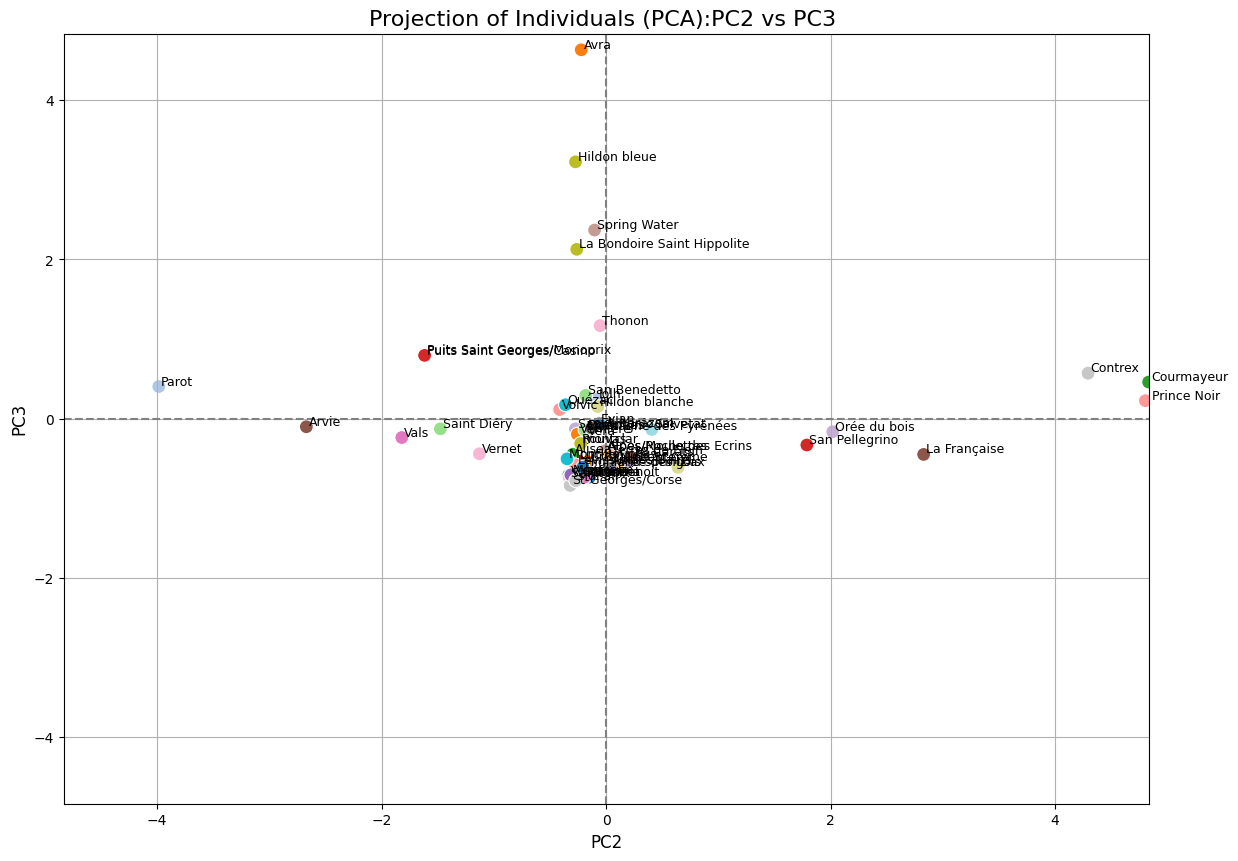

In [ ]:
plt.figure(figsize=(14, 10))

# Scatter plot
sns.scatterplot(
    data=df_individuals.reset_index(),
    x='PC2',
    y='PC3',
    hue='NOM',
    palette='tab20',
    s=100,
    legend=False
)

# Annotate points
for i, row in df_individuals.reset_index().iterrows():
    plt.text(row['PC2']+0.02, row['PC3']+0.02, row['NOM'], fontsize=9)

# Centered axes
max_val = max(abs(df_individuals['PC2'].max()), abs(df_individuals['PC2'].min()),
              abs(df_individuals['PC3'].max()), abs(df_individuals['PC3'].min()))
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)

# Axes lines
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

# Titles and labels
plt.title("Projection of Individuals (PCA):PC2 vs PC3 ", fontsize=16)
plt.xlabel("PC2", fontsize=12)
plt.ylabel("PC3", fontsize=12)
plt.grid(True)
plt.show()

#### **Comment**

The projection of individuals on the PC2 and PC3 axes helps isolate the two most specific factors that differentiate the waters, once overall mineralization (PC1) is removed. This plane contrasts the type of mineralization with the presence of nitrates.

Axis PC2 (horizontal) continues to separate chemical signatures: on the left, we find waters dominated by bicarbonate and sodium (Parot, Arvie), while on the far right are sulfate-calcium waters (Courmayeur, Contrex). This horizontal opposition confirms that these two groups of mineralized waters are chemically very different.

Axis PC3 (vertical) represents the variation of Nitrates (NO3). Sources like Avra and Hildon bleue stand out vertically from the central group, showing unusually high nitrate concentrations compared to the rest of the dataset. This axis acts as an indicator of external input (often human-related), independent from natural geological processes that determine the position of waters on the horizontal axis.

### PCA Conclusion

Principal Component Analysis made it possible to reduce the dataset dimension while keeping most of the information. The first three principal components explain most of the variance, allowing us to go from 8 variables to only 3 main dimensions.

PC1 represents the overall mineralization of the waters, while PC2 separates two opposite chemical groups: sulfate-calcium waters and bicarbonate-sodium waters. PC3 highlights an independent factor related to nitrates (NO3), often linked to external sources.

This analysis helps identify groups of similar waters and some outliers. It provides a strong basis for further analysis, such as clustering, to better classify the different types of water.

## **C.Clustering**

In [ ]:
df_final.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,NOM,ACRO,PAYS,TYPE,PG
0,-0.717882,-0.064378,-0.063202,-0.207095,-0.177457,0.288440,0.167328,0.013164,Evian,EVIAN,F,M,P
1,-0.953360,-0.194812,-0.149791,0.326839,0.012204,0.029059,0.028465,0.003193,Montagne des Pyrénées,MTPYR,F,S,P
2,-0.978482,-0.164889,-0.540574,0.003437,0.068418,-0.218354,0.224356,0.017675,Cristaline-St-Cyr,CRIST,F,S,P
3,-0.381590,0.112462,-0.602030,-0.208141,-0.222471,0.382702,0.200664,-0.003916,Fiée des Lois,FIEE,F,S,P
4,-1.450599,-0.334999,-0.713063,0.151704,0.068483,-0.115600,-0.209983,-0.002456,Volcania,VOLCA,F,S,P


In [ ]:
df_final.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'NOM', 'ACRO',
       'PAYS', 'TYPE', 'PG'],
      dtype='object')

In [ ]:
df_clusters = df_final[['PC1', 'PC2', 'PC3','NOM', 'ACRO','PAYS', 'TYPE', 'PG']]
df_clusters.head()

,PC1,PC2,PC3,NOM,ACRO,PAYS,TYPE,PG
0,-0.717882,-0.064378,-0.063202,Evian,EVIAN,F,M,P
1,-0.953360,-0.194812,-0.149791,Montagne des Pyrénées,MTPYR,F,S,P
2,-0.978482,-0.164889,-0.540574,Cristaline-St-Cyr,CRIST,F,S,P
3,-0.381590,0.112462,-0.602030,Fiée des Lois,FIEE,F,S,P
4,-1.450599,-0.334999,-0.713063,Volcania,VOLCA,F,S,P


### Prepare the data for clustering

In [ ]:
X_cluster = df_clusters[['PC1', 'PC2', 'PC3']]

### Elbow Method

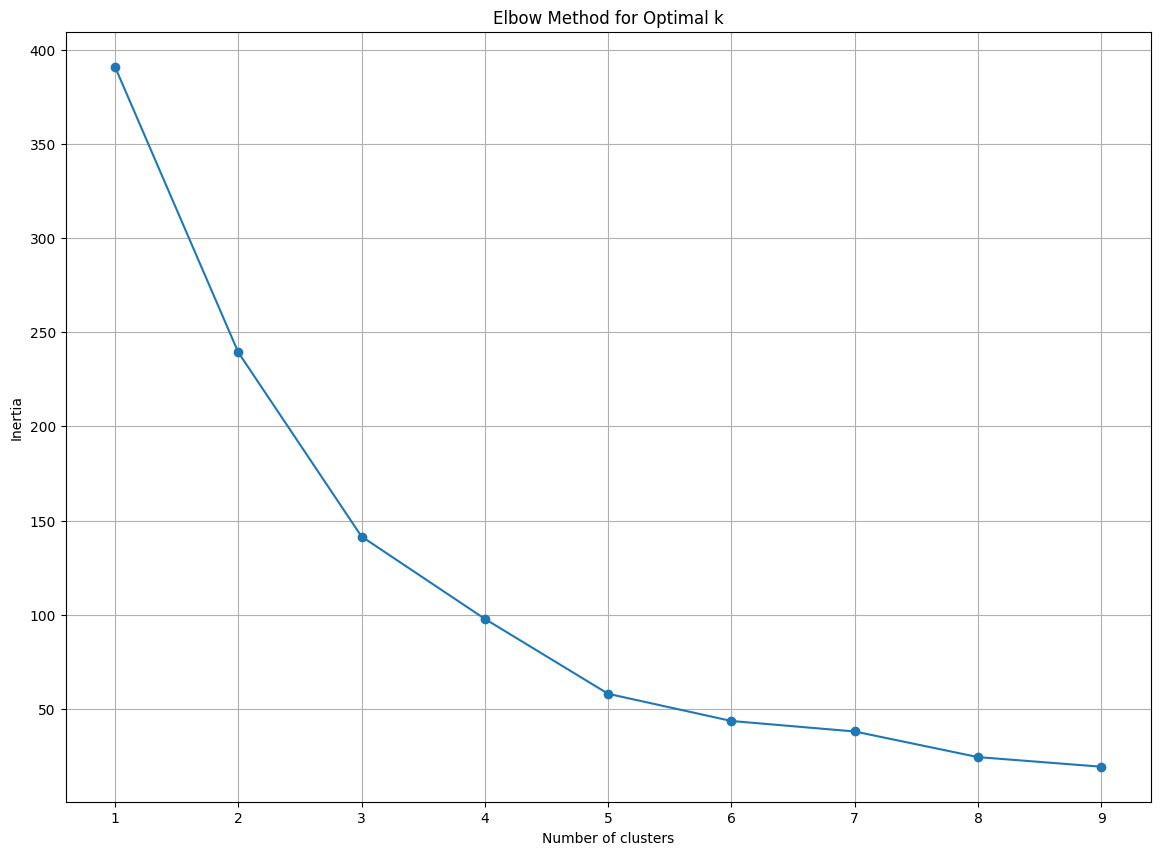

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(14, 10))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

#### **Comment**

The interpretation of this graph using the elbow method helps determine the optimal number of clusters (k) by observing the decrease in inertia (within-group dispersion). The goal is to find the point where adding another cluster does not bring significant improvement.

In this case, we observe a very clear “elbow” at k = 3. This point marks a major change: the inertia drops sharply from 390 to 140, capturing most of the data structure. This is a good and simple choice, confirming the three main chemical groups (low mineralized, sulfate, and bicarbonate) previously identified in the PCA.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_cluster)

df_clusters['Cluster_KMeans'] = clusters_kmeans

/tmp/ipykernel_3071/93376608.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters['Cluster_KMeans'] = clusters_kmeans


In [ ]:
df_clusters['Cluster_KMeans'] = df_clusters['Cluster_KMeans'].map({0:1, 1:2, 2:3})
df_clusters.head()

/tmp/ipykernel_3071/2302483773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters['Cluster_KMeans'] = df_clusters['Cluster_KMeans'].map({0:1, 1:2, 2:3})


,PC1,PC2,PC3,NOM,ACRO,PAYS,TYPE,PG,Cluster_KMeans,Cluster_HAC
0,-0.717882,-0.064378,-0.063202,Evian,EVIAN,F,M,P,3.0,1
1,-0.953360,-0.194812,-0.149791,Montagne des Pyrénées,MTPYR,F,S,P,3.0,1
2,-0.978482,-0.164889,-0.540574,Cristaline-St-Cyr,CRIST,F,S,P,3.0,1
3,-0.381590,0.112462,-0.602030,Fiée des Lois,FIEE,F,S,P,3.0,1
4,-1.450599,-0.334999,-0.713063,Volcania,VOLCA,F,S,P,3.0,1


### Hierarchical clustering (HAC)

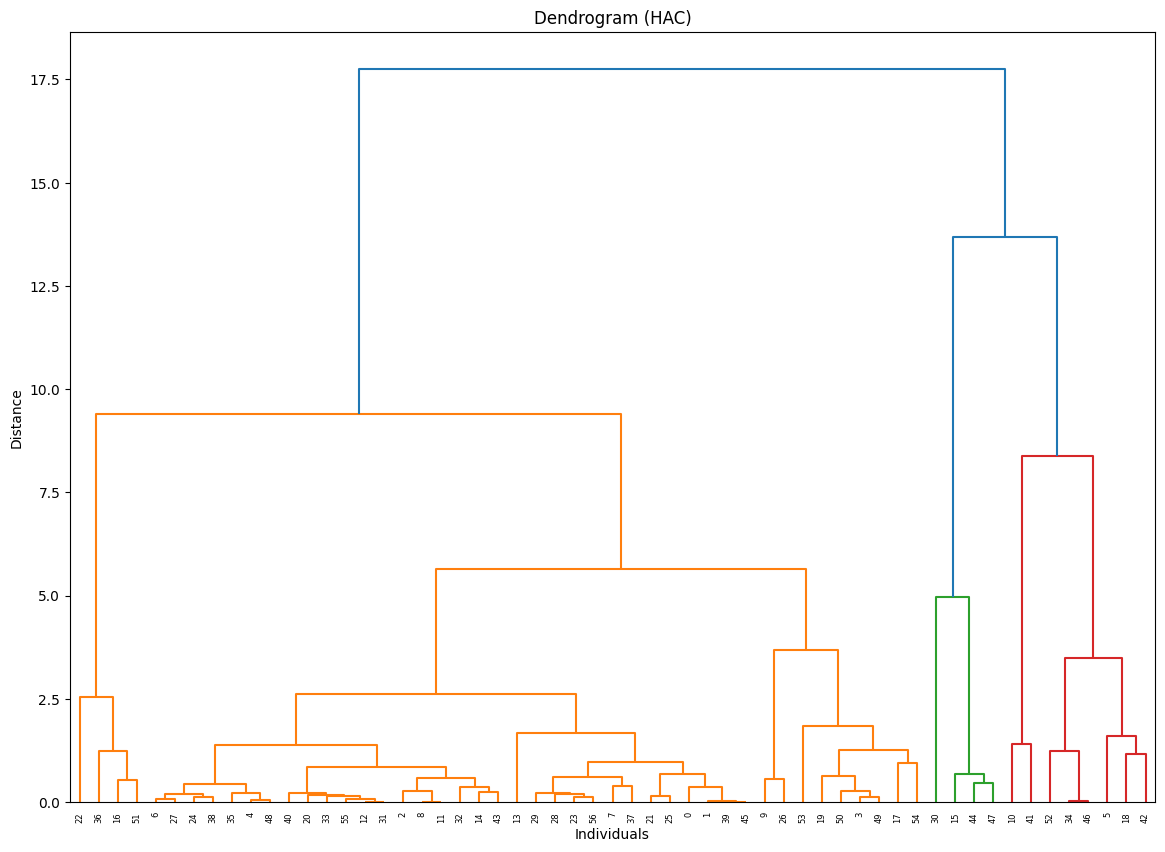

In [ ]:
# With dendogramme
Z = linkage(X_cluster, method='ward')

plt.figure(figsize=(14, 10))
dendrogram(Z, labels=df_clusters.index)
plt.title("Dendrogram (HAC)")
plt.xlabel("Individuals")
plt.ylabel("Distance")
plt.show()

#### **Comment**

By observing the structure of the tree, we can clearly see three main groups. The orange block on the left is the largest and most dense; it includes most of the waters with low to medium mineralization. This group forms the “core” of the dataset, where variations in ions are small, which explains why the branches are short and close together.

The red block on the far right stands out strongly, with a linkage distance higher than 12. This large jump confirms that these waters (probably sulfate-calcium types like Contrex or bicarbonate types like Arvie) have a chemical composition very different from the rest of the samples.

The small green group acts as a transition zone, grouping a few sources with mixed or specific characteristics.

This hierarchical analysis perfectly confirms the previous choice of k = 3 for K-means. By drawing an imaginary horizontal line around a distance of 10, the tree naturally splits into three clear groups. This shows that the classification is not random but based on real and strong chemical differences in the data.

### Split the HAC clusters

In [ ]:
clusters_hac = fcluster(Z, t=3, criterion='maxclust')

df_clusters['Cluster_HAC'] = clusters_hac
df_clusters.head()

/tmp/ipykernel_3071/635686331.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters['Cluster_HAC'] = clusters_hac


,PC1,PC2,PC3,NOM,ACRO,PAYS,TYPE,PG,Cluster_KMeans,Cluster_HAC
0,-0.717882,-0.064378,-0.063202,Evian,EVIAN,F,M,P,1,1
1,-0.953360,-0.194812,-0.149791,Montagne des Pyrénées,MTPYR,F,S,P,1,1
2,-0.978482,-0.164889,-0.540574,Cristaline-St-Cyr,CRIST,F,S,P,1,1
3,-0.381590,0.112462,-0.602030,Fiée des Lois,FIEE,F,S,P,1,1
4,-1.450599,-0.334999,-0.713063,Volcania,VOLCA,F,S,P,1,1


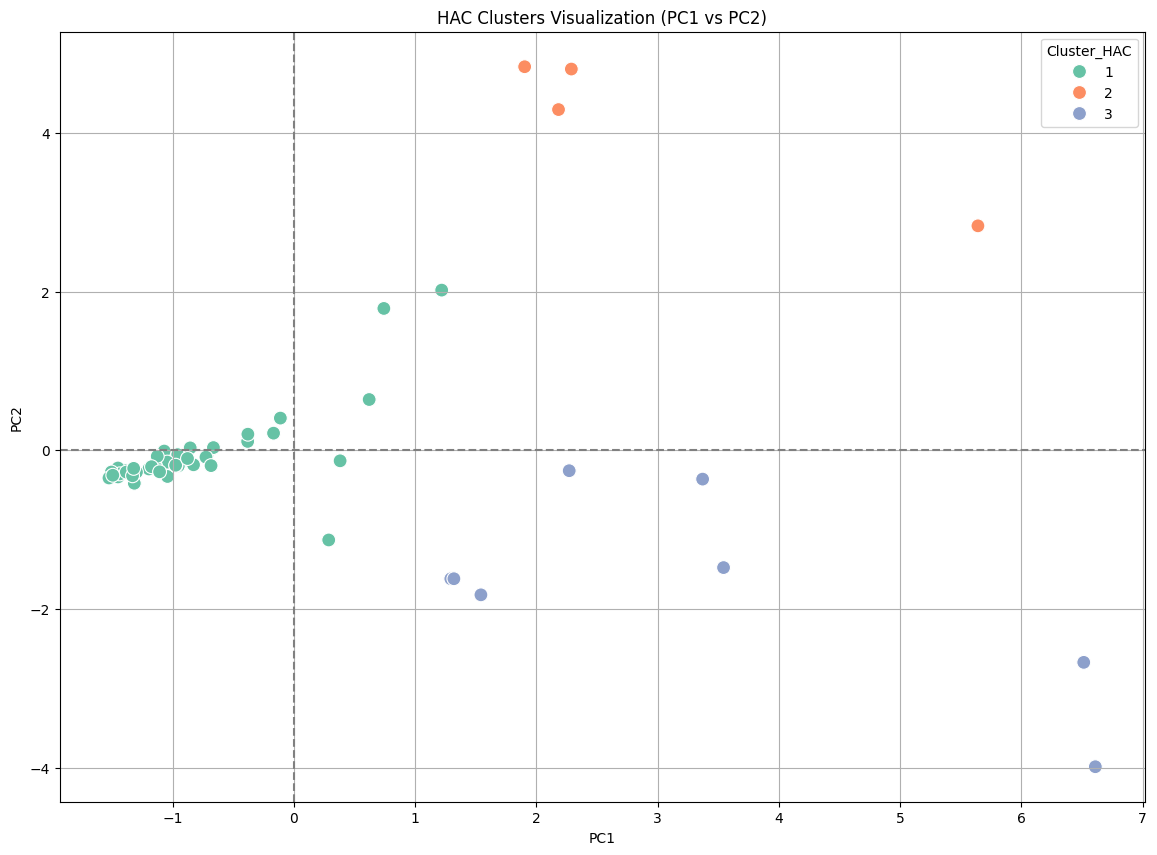

In [ ]:
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=df_clusters.reset_index(),
    x='PC1',
    y='PC2',
    hue='Cluster_HAC',
    palette='Set2',
    s=100
)

# Axes centrés
plt.axhline(0, linestyle='--', color='grey')
plt.axvline(0, linestyle='--', color='grey')

plt.title("HAC Clusters Visualization (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid(True)
plt.show()

#### **Comment**

The final visualization of HAC (Hierarchical Clustering) on the PCA plane confirms the geochemical structure of the data into three distinct groups. Cluster 1 (in green) includes most of the samples located on the left side of the horizontal axis. It represents waters with low overall mineralization, forming the base group of drinking waters with balanced chemical composition and values close to natural levels.

Cluster 2 (in orange) is located in the upper right area, representing the sulfate-calcium group. Its high position on the vertical axis shows a strong mineral signature, dominated by calcium and sulfates. By clearly separating from the main group, these waters show specific hydrochemical characteristics that make them very different from common drinking waters.

Finally, Cluster 3 (in blue) extends to the lower right part of the graph, corresponding to the bicarbonate-sodium group. The alignment of these points shows that, even with different levels of total mineralization, these waters share a strong dominance of sodium and bicarbonates.

This final clustering confirms the consistency of the method: it transforms complex variables into three clear and meaningful geochemical groups.

### Clustering Conclusion

Clustering Conclusion:

The clustering analysis, using both K-means and Hierarchical Clustering (HAC), confirmed the presence of three well-defined groups in the data. The elbow method clearly indicated that k = 3 is the optimal number of clusters, which is consistent with the structure observed in the PCA.

These clusters correspond to three main types of waters: low-mineralized waters, sulfate-calcium waters, and bicarbonate-sodium waters. Both methods produced similar groupings, showing the robustness and reliability of the classification.

Overall, clustering provided a clear segmentation of the dataset and validated the patterns identified by PCA. It highlights the existence of distinct geochemical profiles and simplifies the interpretation of complex chemical data.

# **Overall Conclusion**


The analyses helped to better understand the chemical structure of the studied waters. The exploratory analysis showed high variability in concentrations and the presence of extreme values, which justified using appropriate statistical methods.

PCA effectively reduced the data dimensions while keeping most of the information. It revealed that total mineralization, the dominant types of ions, and the presence of nitrates are the main factors that differentiate the waters.

Clustering methods then confirmed the existence of three distinct groups: low-mineralized waters, sulfate-calcium waters, and bicarbonate-sodium waters. This segmentation is consistent with the PCA results and highlights well-defined geochemical profiles.

In conclusion, this work shows that combining PCA with clustering is an effective approach for analyzing and interpreting complex chemical data. It allows transforming multiple variables into a clear structure, making it easier to understand and classify the waters.